In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
 
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path: sys.path.insert(0, ROOT)

FILTERED_DIR='../filtered'; CKPT_DIR='../checkpoints'

 
# --- Edit these paths to match your project ---
TRAIN_DIR  = '../filtered'
TEST_DIR  = ['../filtered_test']
STRIDE     = 5             # subsample training data
HEXBIN_GS  = 60            # density grid resolution
 
COLS = ['pos1', 'pos2', 'vel1', 'vel2', 'tau1', 'tau2']
TEST_COLS = ['pos1', 'pos2', 'vel1', 'vel2']
 

In [2]:
train_files = sorted(glob.glob(os.path.join(TRAIN_DIR, '*.csv')))
print(f'Found {len(train_files)} training files in {TRAIN_DIR}')
 
parts = []
for fp in train_files:
    try:
        df = pd.read_csv(fp, usecols=lambda c: c in COLS)
        for c in COLS:
            if c not in df.columns: df[c] = np.nan
        parts.append(df[COLS].to_numpy()[::STRIDE])
    except Exception as e:
        print(f'  skipped {os.path.basename(fp)}: {e}')
 
train_data = np.vstack(parts)
train_data = train_data[~np.isnan(train_data).any(axis=1)]
q1, q2, qd1, qd2, tau1, tau2 = train_data.T
print(f'Total samples after stride={STRIDE}: {len(train_data):,}')
 
print('\nRanges:')
for name, data in zip(['q1','q2','qd1','qd2','tau1','tau2'],
                      [q1, q2, qd1, qd2, tau1, tau2]):
    print(f'  {name:5s}  range=[{data.min():+.3f}, {data.max():+.3f}]'
          f'  mean={data.mean():+.4f}  std={data.std():.4f}')
 
 

Found 91 training files in ../filtered
Total samples after stride=5: 158,878

Ranges:
  q1     range=[-27.629, +32.497]  mean=+0.6522  std=4.4690
  q2     range=[-8.284, +3.132]  mean=-0.0507  std=0.9366
  qd1    range=[-12.222, +12.717]  mean=+0.0627  std=1.1580
  qd2    range=[-28.965, +25.568]  mean=-0.0131  std=0.9710
  tau1   range=[-0.144, +0.142]  mean=+0.0026  std=0.0508
  tau2   range=[-0.061, +0.077]  mean=+0.0005  std=0.0146


In [3]:
test_pos_data = {}
for test_dir in TEST_DIR:
    if not os.path.isdir(test_dir):
        print(f'  (skipping: {test_dir} not found)')
        continue
    for fp in sorted(glob.glob(os.path.join(test_dir, '*.csv'))):
        name = os.path.basename(fp).replace('.csv', '')
        try:
            df = pd.read_csv(fp)
            if all(c in df.columns for c in TEST_COLS):
                test_pos_data[name] = df[TEST_COLS].to_numpy()
        except Exception:
            pass
print(f'Loaded {len(test_pos_data)} test trajectories: {list(test_pos_data.keys())}')
 

Loaded 21 test trajectories: ['169_data_02', '169_data_05', '169_data_08', '169_data_101', '169_data_102', '169_data_103', '169_datastress_06', '16_data_03', '16_data_06', '16_data_09', '16_data_101', '16_data_11', '16_datastress_09', '171_data_01', '171_data_04', '171_data_07', '171_data_10', '171_data_101', '171_data_102', '171_data_103', '171_datastress_05']


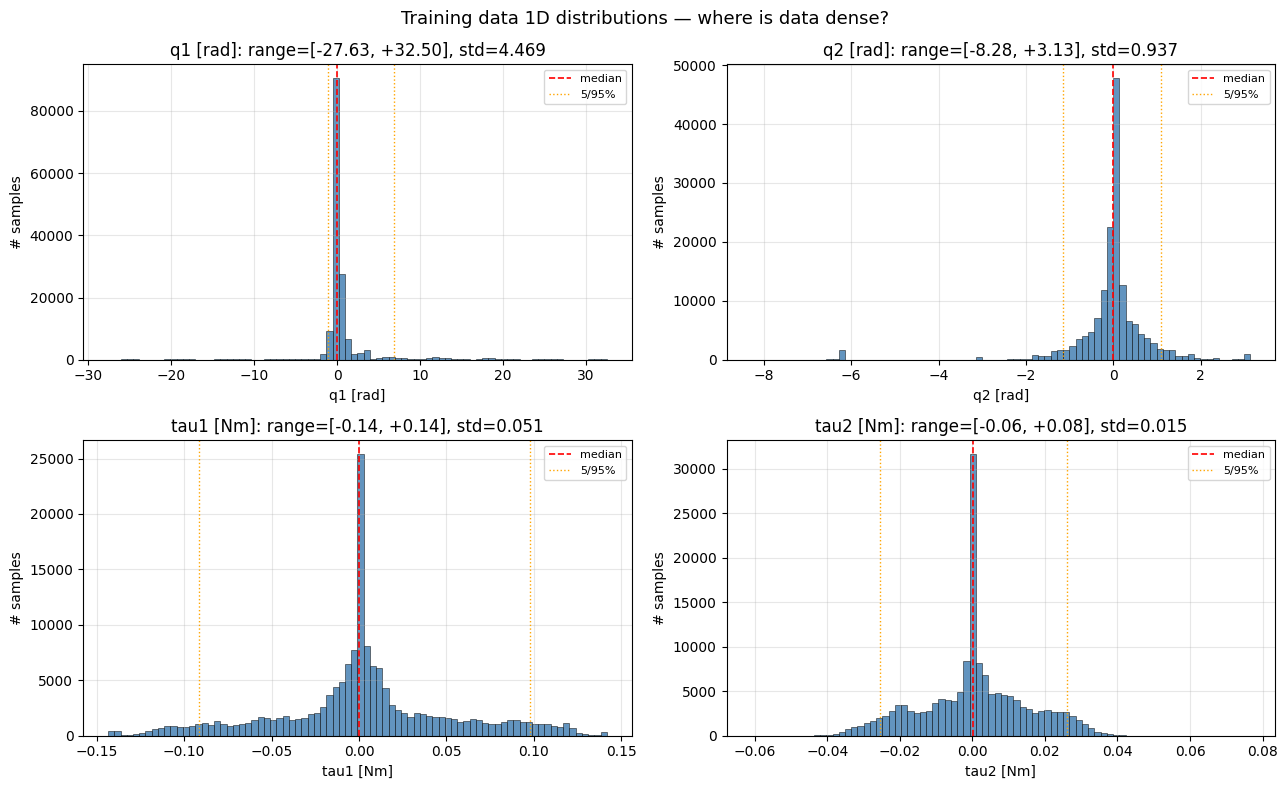

In [4]:
var_names = ['q1 [rad]', 'q2 [rad]', 'tau1 [Nm]', 'tau2 [Nm]']
var_data  = [q1, q2, tau1, tau2]
 
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, name, data in zip(axes.flat, var_names, var_data):
    ax.hist(data, bins=80, color='steelblue', alpha=0.85,
            edgecolor='k', linewidth=0.4)
    ax.set_xlabel(name); ax.set_ylabel('# samples')
    ax.set_title(f'{name}: range=[{data.min():+.2f}, {data.max():+.2f}], '
                 f'std={data.std():.3f}')
    ax.grid(True, alpha=0.3)
    ax.axvline(np.median(data), color='red', ls='--', lw=1.2, label='median')
    p05, p95 = np.percentile(data, [5, 95])
    ax.axvline(p05, color='orange', ls=':', lw=1.0, label='5/95%')
    ax.axvline(p95, color='orange', ls=':', lw=1.0)
    ax.legend(fontsize=8)
fig.suptitle('Training data 1D distributions — where is data dense?', fontsize=13)
plt.tight_layout(); plt.show()
 

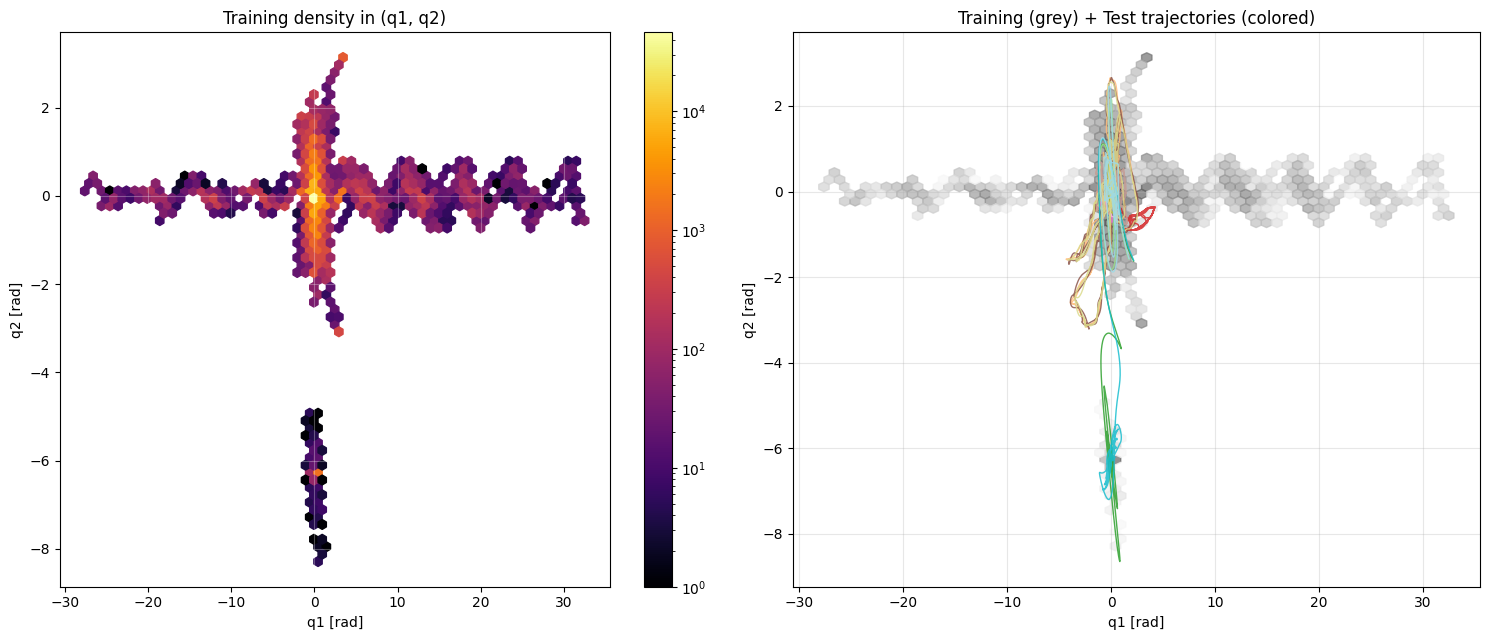

In [5]:
ig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
ax = axes[0]
hb = ax.hexbin(q1, q2, gridsize=HEXBIN_GS, cmap='inferno',
               norm=LogNorm(), mincnt=1)
ax.set_xlabel('q1 [rad]'); ax.set_ylabel('q2 [rad]')
ax.set_title('Training density in (q1, q2)')
ax.grid(True, alpha=0.3, color='white')
plt.colorbar(hb, ax=ax)
 
ax = axes[1]
ax.hexbin(q1, q2, gridsize=HEXBIN_GS, cmap='Greys',
          norm=LogNorm(), mincnt=1, alpha=0.7)
if test_pos_data:
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(test_pos_data), 1)))
    for (name, data), color in zip(test_pos_data.items(), colors):
        ax.plot(data[:, 0], data[:, 1], '-', color=color, lw=1.0,
                alpha=0.85, label=name)
ax.set_xlabel('q1 [rad]'); ax.set_ylabel('q2 [rad]')
ax.set_title('Training (grey) + Test trajectories (colored)')
ax.grid(True, alpha=0.3)
if test_pos_data and len(test_pos_data) <= 14:
    ax.legend(fontsize=7, loc='best', ncol=2)
plt.tight_layout(); plt.show()
 

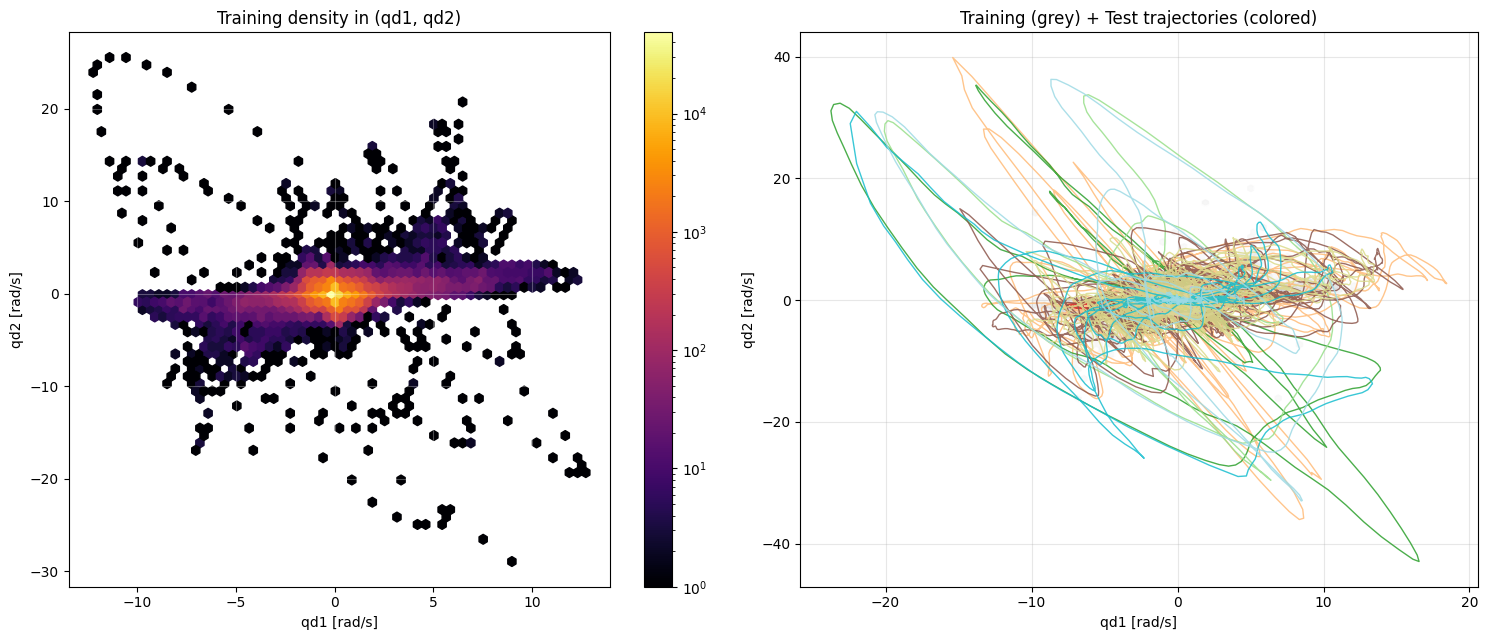

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
ax = axes[0]
hb = ax.hexbin(qd1, qd2, gridsize=HEXBIN_GS, cmap='inferno',
               norm=LogNorm(), mincnt=1)
ax.set_xlabel('qd1 [rad/s]'); ax.set_ylabel('qd2 [rad/s]')
ax.set_title('Training density in (qd1, qd2)')
ax.grid(True, alpha=0.3, color='white')
plt.colorbar(hb, ax=ax)
 
ax = axes[1]
ax.hexbin(qd1, qd2, gridsize=HEXBIN_GS, cmap='Greys',
          norm=LogNorm(), mincnt=1, alpha=0.7)
if test_pos_data:
    for (name, data), color in zip(test_pos_data.items(), colors):
        ax.plot(data[:, 2], data[:, 3], '-', color=color, lw=1.0,
                alpha=0.85, label=name)
ax.set_xlabel('qd1 [rad/s]'); ax.set_ylabel('qd2 [rad/s]')
ax.set_title('Training (grey) + Test trajectories (colored)')
ax.grid(True, alpha=0.3)
if test_pos_data and len(test_pos_data) <= 14:
    ax.legend(fontsize=7, loc='best', ncol=2)
plt.tight_layout(); plt.show()
 

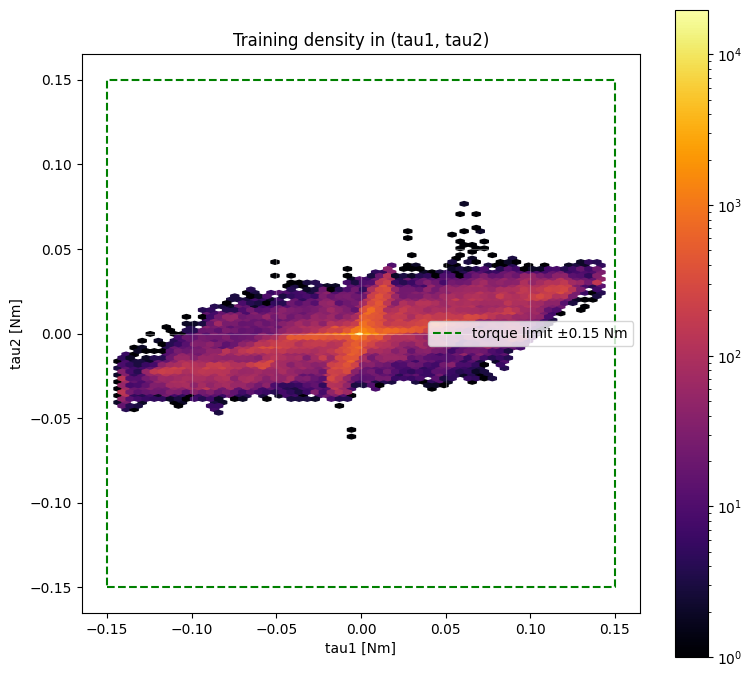

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(tau1, tau2, gridsize=HEXBIN_GS, cmap='inferno',
               norm=LogNorm(), mincnt=1)
limit = 0.15
ax.plot([-limit, limit, limit, -limit, -limit],
        [-limit, -limit, limit, limit, -limit],
        'g--', lw=1.5, label='torque limit ±0.15 Nm')
ax.set_xlabel('tau1 [Nm]'); ax.set_ylabel('tau2 [Nm]')
ax.set_title('Training density in (tau1, tau2)')
ax.grid(True, alpha=0.3, color='white')
plt.colorbar(hb, ax=ax); ax.legend(fontsize=10); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
 

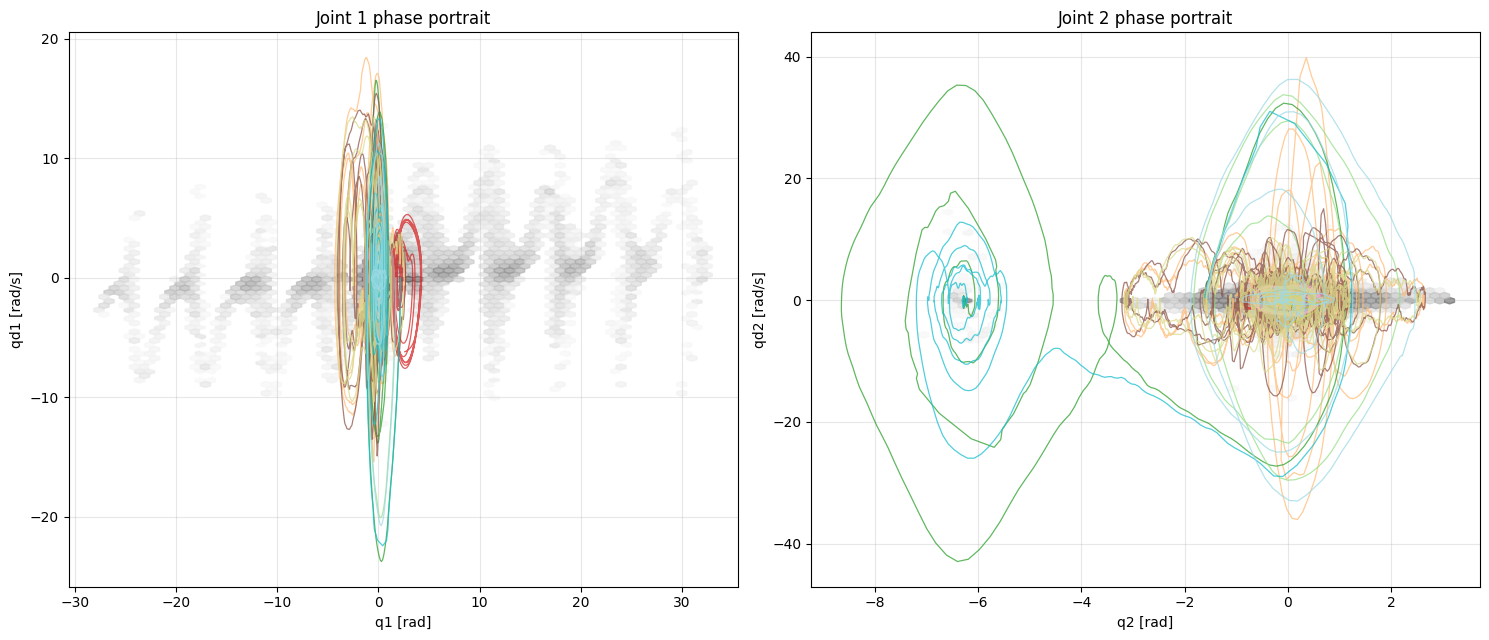

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
 
ax = axes[0]
ax.hexbin(q1, qd1, gridsize=HEXBIN_GS, cmap='Greys',
          norm=LogNorm(), mincnt=1, alpha=0.7)
if test_pos_data:
    for (name, data), color in zip(test_pos_data.items(), colors):
        ax.plot(data[:, 0], data[:, 2], '-', color=color, lw=0.9,
                alpha=0.75, label=name)
ax.set_xlabel('q1 [rad]'); ax.set_ylabel('qd1 [rad/s]')
ax.set_title('Joint 1 phase portrait')
ax.grid(True, alpha=0.3)
if test_pos_data and len(test_pos_data) <= 14:
    ax.legend(fontsize=7, loc='best', ncol=2)
 
ax = axes[1]
ax.hexbin(q2, qd2, gridsize=HEXBIN_GS, cmap='Greys',
          norm=LogNorm(), mincnt=1, alpha=0.7)
if test_pos_data:
    for (name, data), color in zip(test_pos_data.items(), colors):
        ax.plot(data[:, 1], data[:, 3], '-', color=color, lw=0.9, alpha=0.75)
ax.set_xlabel('q2 [rad]'); ax.set_ylabel('qd2 [rad/s]')
ax.set_title('Joint 2 phase portrait')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
 
 

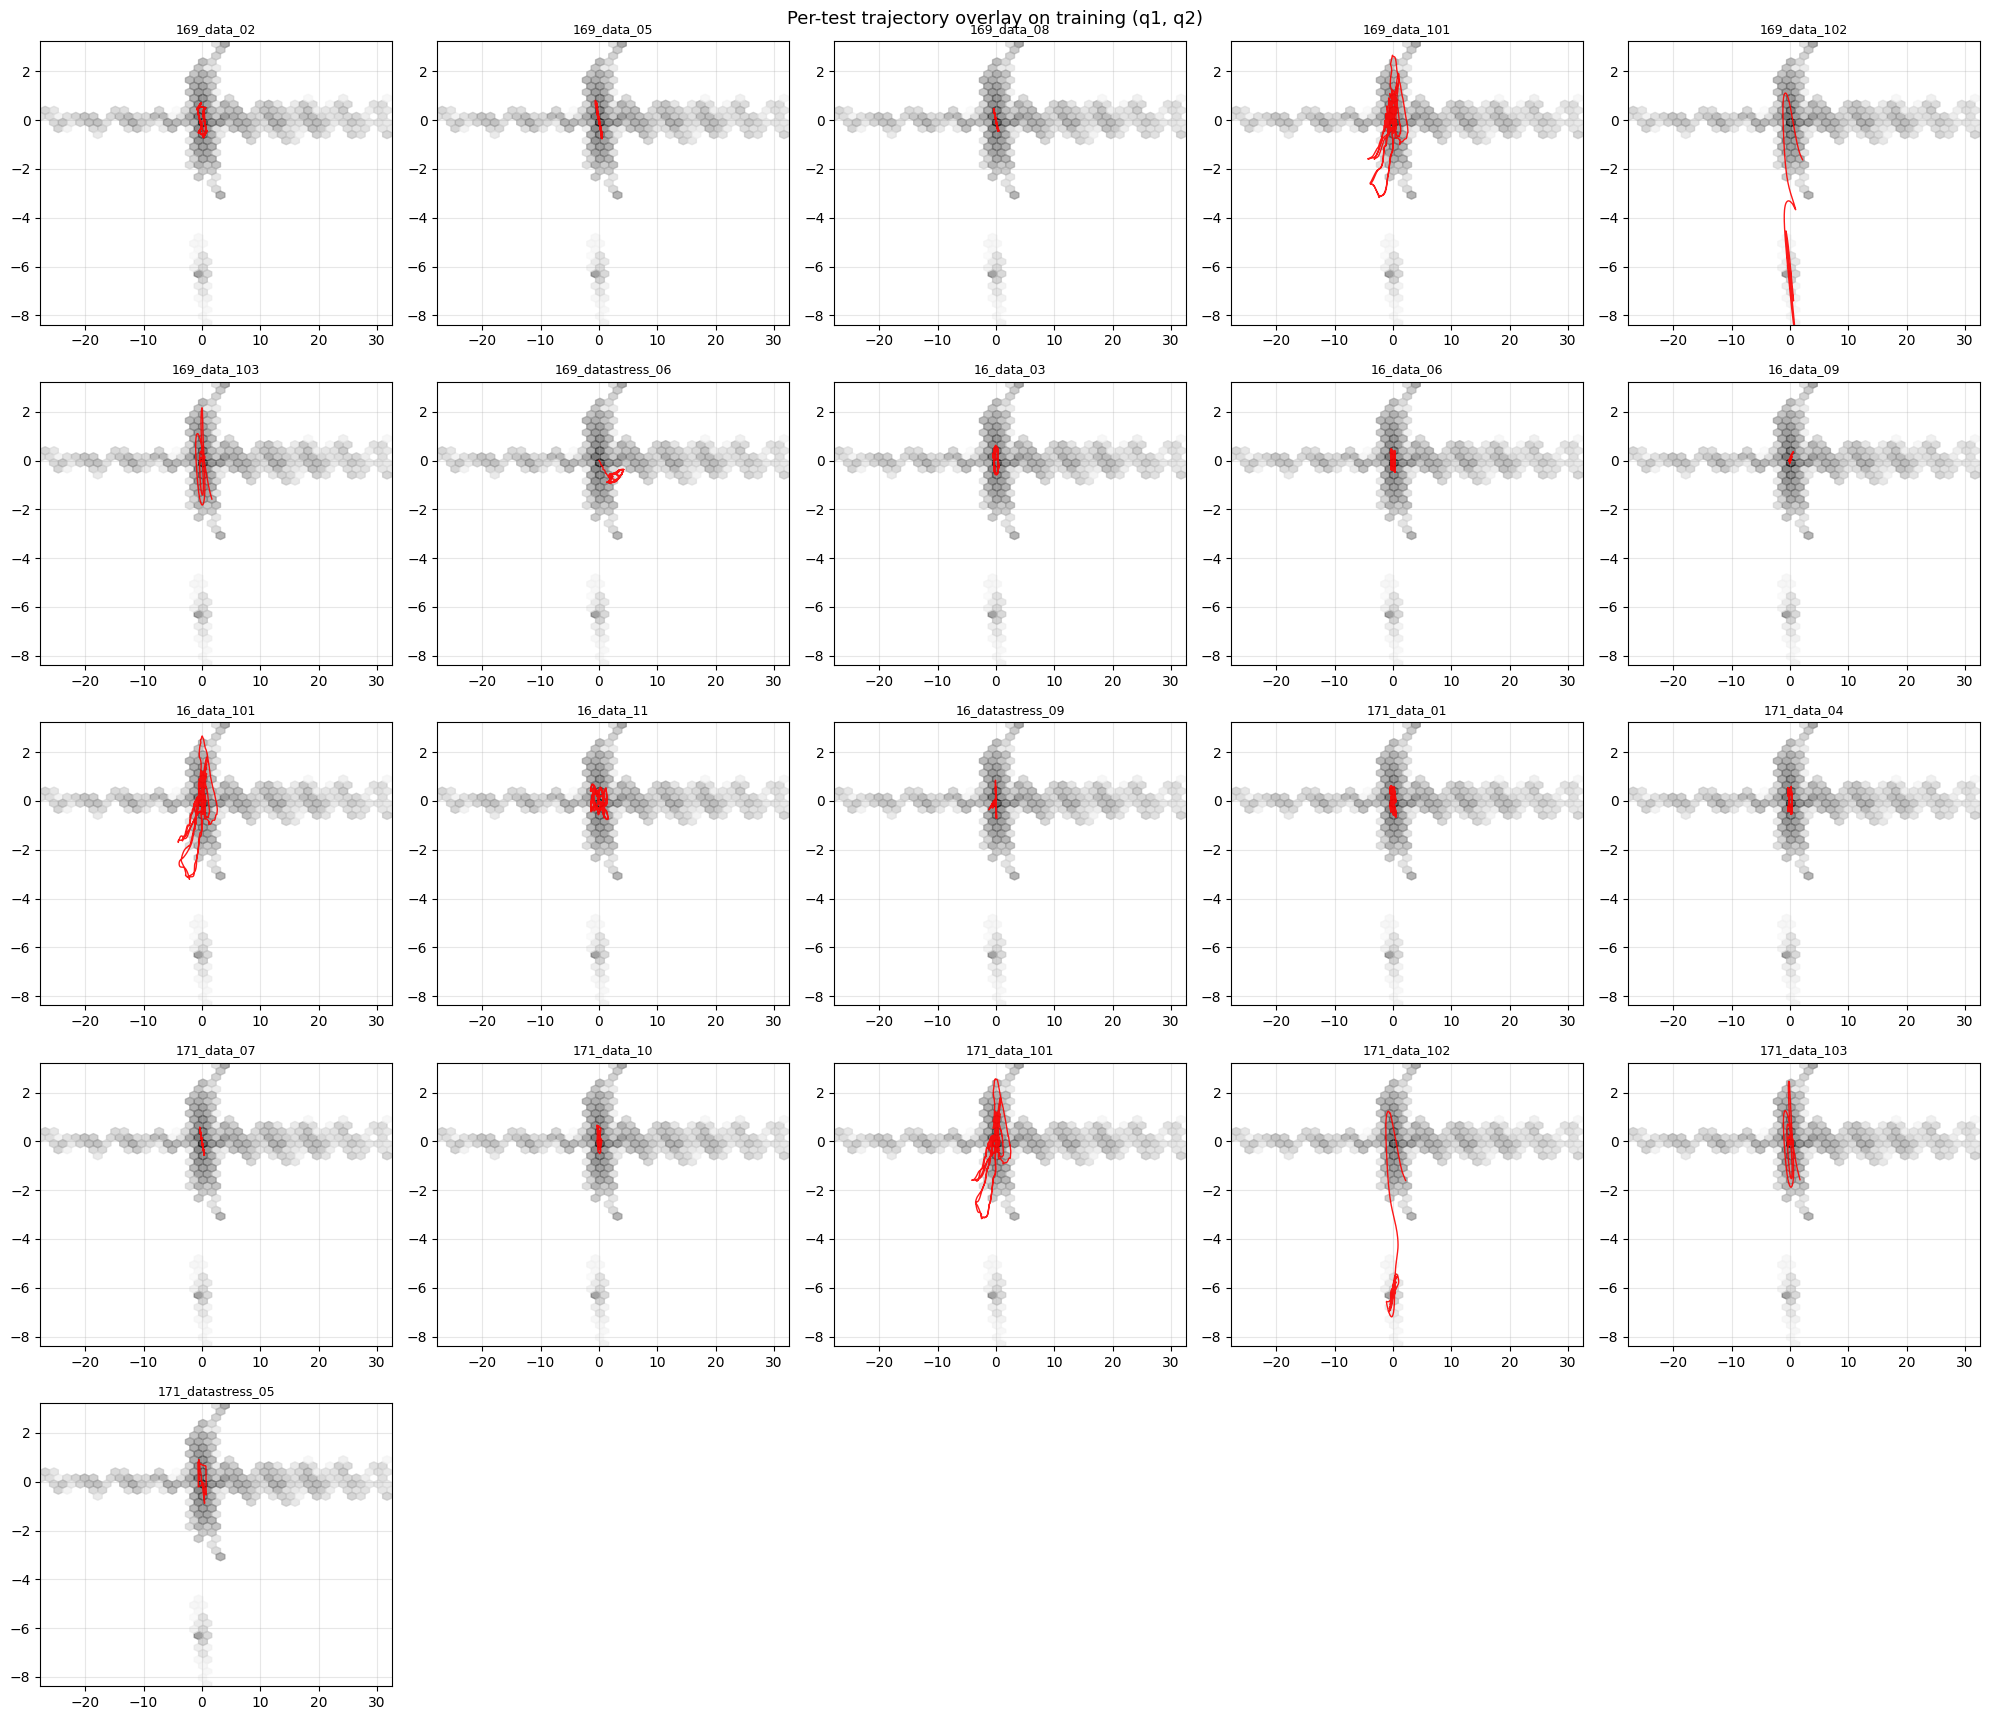

In [9]:
if test_pos_data:
    n_tests = len(test_pos_data)
    ncols = 5
    nrows = int(np.ceil(n_tests / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0*ncols, 3.5*nrows),
                             squeeze=False)
    for idx, (name, data) in enumerate(test_pos_data.items()):
        ax = axes[idx // ncols, idx % ncols]
        ax.hexbin(q1, q2, gridsize=40, cmap='Greys',
                  norm=LogNorm(), mincnt=1, alpha=0.6)
        ax.plot(data[:, 0], data[:, 1], '-', color='red', lw=1.0, alpha=0.9)
        ax.set_title(name, fontsize=9)
        ax.set_xlim(q1.min()-0.1, q1.max()+0.1)
        ax.set_ylim(q2.min()-0.1, q2.max()+0.1)
        ax.grid(True, alpha=0.3)
    for k in range(n_tests, nrows*ncols):
        axes[k // ncols, k % ncols].axis('off')
    fig.suptitle('Per-test trajectory overlay on training (q1, q2)', fontsize=13)
    plt.tight_layout(); plt.show()
 
 

In [10]:
from scipy.spatial import cKDTree
 
# Scale dimensions so units are comparable (position ~rad, velocity ~rad/s)
scale = np.array([1.0, 1.0, 0.2, 0.2])    # downweight velocity by 5x
train_states = train_data[:, :4] * scale[None]
tree = cKDTree(train_states)
 
print(f'{"Test":<25s}  {"median nn":>10s}  {"90% nn":>10s}  {"max nn":>10s}'
      f'  {"verdict":>20s}')
print('-' * 80)
for name, data in test_pos_data.items():
    test_states = data[::10] * scale[None]   # subsample for speed
    d, _ = tree.query(test_states, k=1)
    med = np.median(d); p90 = np.percentile(d, 90); mx = d.max()
    if med < 0.05:    verdict = 'interpolating'
    elif med < 0.15:  verdict = 'near boundary'
    else:             verdict = 'EXTRAPOLATING'
    print(f'{name:<25s}  {med:>10.3f}  {p90:>10.3f}  {mx:>10.3f}  {verdict:>20s}')
 
 

Test                        median nn      90% nn      max nn               verdict
--------------------------------------------------------------------------------
169_data_02                     0.077       0.231       0.494         near boundary
169_data_05                     0.059       0.347       0.630         near boundary
169_data_08                     0.036       0.064       0.088         interpolating
169_data_101                    0.146       1.367       4.505         near boundary
169_data_102                    0.015       1.332       5.873         interpolating
169_data_103                    0.009       0.655       4.244         interpolating
169_datastress_06               0.334       0.910       1.635         EXTRAPOLATING
16_data_03                      0.096       0.131       0.170         near boundary
16_data_06                      0.062       0.097       0.127         near boundary
16_data_09                      0.013       0.032       0.123         interpola